# 04. Training & Evaluation

Notebook ini **fokus penuh pada eksperimen**: melatih 6 skenario eksperimen (E1–E6) yang arsitekturnya sudah didefinisikan secara eksplisit di `03_Modeling_ANN.ipynb`, mengevaluasi masing-masing dengan metrik yang relevan untuk data tidak seimbang (precision, recall, F1-score per kelas, macro & weighted average, confusion matrix), lalu memilih model terbaik untuk disimpan. 

**Pipeline notebook:** `00_Data_Exploration` → `01_Data_Preprocessing` → `02_Feature_Engineering` → `03_Modeling_ANN` → `04_Training_Evaluation` → `05_SHAP_Explainability` → `06_Deployment`

**Tahapan pada notebook ini:**
1. Memuat dataset train/val/test hasil `02_Feature_Engineering.ipynb`
2. Encoding label & perhitungan class weight
3. Melatih 6 skenario eksperimen dengan Early Stopping
4. Evaluasi tiap skenario pada test set
5. Membandingkan hasil & memilih model terbaik (macro F1-score, karena fokus pada kemampuan mengenali kelas minoritas)
6. Menyimpan model terbaik & riwayat eksperimen

---

## Import Library

In [6]:
import sys, os, json, time
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_fscore_support, accuracy_score,
)

from io_utils import DATA_PROCESSED, MODELS, REPORTS, load_json, save_json
from model import build_ann_model, EXPERIMENTS

warnings_seed = 42
np.random.seed(warnings_seed)
tf.random.set_seed(warnings_seed)
sns.set_theme(style='whitegrid')

## Memuat Dataset Train/Val/Test

In [7]:
selected_features = load_json('selected_features.json')
label_names = {int(k): v for k, v in load_json('label_names.json').items()}

train_df = pd.read_parquet(os.path.join(DATA_PROCESSED, 'train.parquet'))
val_df = pd.read_parquet(os.path.join(DATA_PROCESSED, 'val.parquet'))
test_df = pd.read_parquet(os.path.join(DATA_PROCESSED, 'test.parquet'))

X_train, y_train = train_df[selected_features].values, train_df['risk_class'].values
X_val, y_val = val_df[selected_features].values, val_df['risk_class'].values
X_test, y_test = test_df[selected_features].values, test_df['risk_class'].values

input_dim = X_train.shape[1]
n_classes = len(label_names)

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Fitur ({input_dim}): {selected_features}')
print(f'Kelas ({n_classes}): {label_names}')

Train: (621165, 15) | Val: (133107, 15) | Test: (133107, 15)
Fitur (15): ['inq_last_6mths', 'int_rate', 'total_rev_hi_lim', 'term', 'tot_cur_bal', 'loan_amnt', 'open_acc', 'dti', 'installment', 'revol_util', 'pub_rec', 'revol_bal', 'delinq_2yrs', 'annual_inc', 'emp_length']
Kelas (4): {0: 'Prime', 1: 'Performing', 2: 'Under-performing', 3: 'Non-Performing'}


## Perhitungan Class Weight (untuk skenario E5 & E6)

In [8]:
classes = np.unique(y_train)
cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes.tolist(), cw.tolist()))

print('Class weight (balanced):')
for k, v in class_weight_dict.items():
    print(f'  {label_names[k]}: {v:.3f}')

Class weight (balanced):
  Prime: 1.058
  Performing: 0.364
  Under-performing: 25.766
  Non-Performing: 3.772


## Fungsi Bantuan: Training & Evaluasi Satu Eksperimen

Setiap eksperimen dilatih dengan optimizer Adam, loss *sparse categorical cross-entropy*, serta EarlyStopping (memantau `val_loss`) sebagai bagian dari strategi regularisasi.

In [9]:
def run_experiment(exp_id, config, epochs=100, batch_size=256, verbose=2):
    """Melatih & mengevaluasi satu skenario eksperimen (E1..E6)."""
    model = build_ann_model(
        input_dim=input_dim,
        n_classes=n_classes,
        use_dropout=config['use_dropout'],
        use_batchnorm=config['use_batchnorm'],
        name=f'ann_{exp_id.lower()}',
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=10, restore_best_weights=True
        )
    ]

    fit_kwargs = dict(
        x=X_train, y=y_train,
        validation_data=(X_val, y_val),
        epochs=epochs, batch_size=batch_size,
        callbacks=callbacks, verbose=verbose,
    )
    if config['use_class_weight']:
        fit_kwargs['class_weight'] = class_weight_dict

    t0 = time.time()
    history = model.fit(**fit_kwargs)
    train_time = time.time() - t0

    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    acc = accuracy_score(y_test, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted', zero_division=0
    )

    result = {
        'exp_id': exp_id,
        'description': config['description'],
        'accuracy': acc,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'precision_weighted': precision_w,
        'recall_weighted': recall_w,
        'f1_weighted': f1_w,
        'epochs_trained': len(history.history['loss']),
        'train_time_sec': round(train_time, 1),
    }
    return model, history, y_pred, result

## Menjalankan 6 Skenario Eksperimen

In [10]:
trained_models = {}
histories = {}
predictions = {}
results = []

for exp_id, config in EXPERIMENTS.items():
    print(f'Menjalankan {exp_id}: {config["description"]} ...')
    model, history, y_pred, result = run_experiment(exp_id, config)
    trained_models[exp_id] = model
    histories[exp_id] = history.history
    predictions[exp_id] = y_pred
    results.append(result)
    print(f'  -> accuracy={result["accuracy"]:.4f} | '
          f'f1_macro={result["f1_macro"]:.4f} | '
          f'epochs={result["epochs_trained"]}')

results_df = pd.DataFrame(results).set_index('exp_id')
results_df

Menjalankan E1: Baseline ANN ...
Epoch 1/100
2427/2427 - 8s - 3ms/step - accuracy: 0.7311 - loss: 0.7178 - val_accuracy: 0.7442 - val_loss: 0.6952
Epoch 2/100
2427/2427 - 6s - 2ms/step - accuracy: 0.7440 - loss: 0.6903 - val_accuracy: 0.7453 - val_loss: 0.6901
Epoch 3/100
2427/2427 - 12s - 5ms/step - accuracy: 0.7448 - loss: 0.6868 - val_accuracy: 0.7454 - val_loss: 0.6874
Epoch 4/100
2427/2427 - 6s - 2ms/step - accuracy: 0.7454 - loss: 0.6850 - val_accuracy: 0.7459 - val_loss: 0.6862
Epoch 5/100
2427/2427 - 6s - 2ms/step - accuracy: 0.7455 - loss: 0.6838 - val_accuracy: 0.7454 - val_loss: 0.6856
Epoch 6/100
2427/2427 - 12s - 5ms/step - accuracy: 0.7456 - loss: 0.6827 - val_accuracy: 0.7459 - val_loss: 0.6852
Epoch 7/100
2427/2427 - 6s - 2ms/step - accuracy: 0.7458 - loss: 0.6818 - val_accuracy: 0.7458 - val_loss: 0.6851
Epoch 8/100
2427/2427 - 6s - 2ms/step - accuracy: 0.7460 - loss: 0.6810 - val_accuracy: 0.7460 - val_loss: 0.6841
Epoch 9/100
2427/2427 - 6s - 2ms/step - accuracy: 0.7

,description,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,epochs_trained,train_time_sec
exp_id,,,,,,,,,,
E1,Baseline ANN,0.746369,0.437464,0.317412,0.314880,0.707576,0.746369,0.681364,18,129.4
E2,ANN + Dropout,0.746249,0.381896,0.315032,0.312024,0.696323,0.746249,0.678674,54,606.5
E3,ANN + Batch Normalization,0.746738,0.491813,0.318695,0.317548,0.722904,0.746738,0.682312,25,427.4
E4,ANN + Dropout + Batch Normalization,0.746640,0.381266,0.315576,0.312683,0.696025,0.746640,0.679446,51,1140.2
E5,ANN + Class Weight,0.435740,0.365621,0.402912,0.312309,0.696129,0.435740,0.522886,28,167.7
E6,ANN + Dropout + Class Weight,0.489148,0.376150,0.402835,0.328510,0.697063,0.489148,0.569248,22,154.5


## Perbandingan Hasil Eksperimen

Model terbaik dipilih berdasarkan **F1-score macro** (bukan accuracy), karena macro-average memberi bobot setara ke semua kelas, termasuk kelas minoritas Under-performing & Non-Performing yang justru paling penting untuk dideteksi dalam konteks risiko kredit.

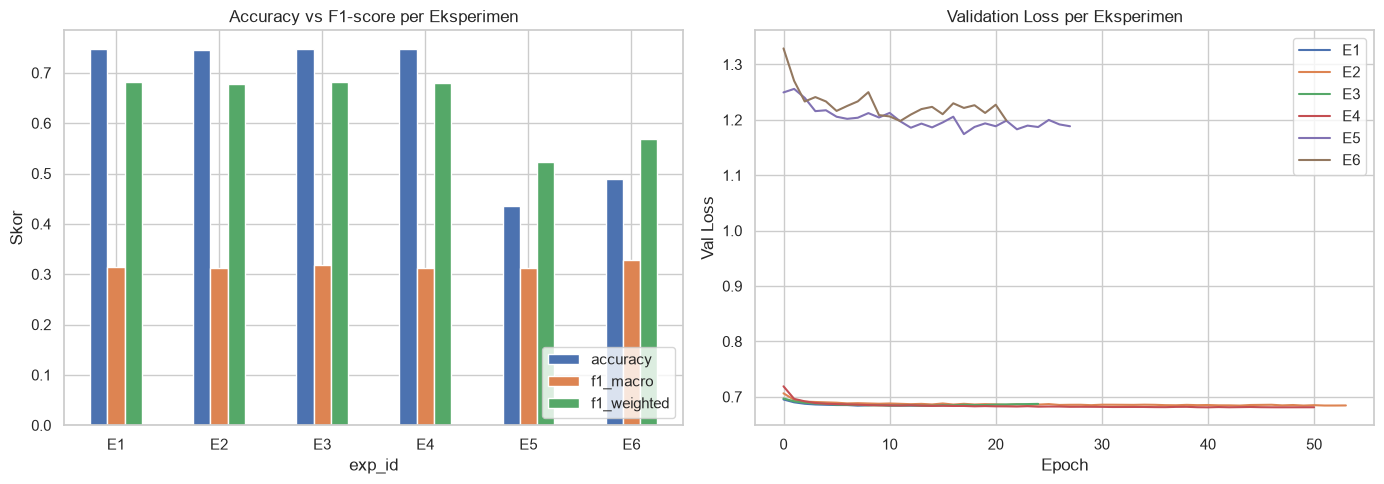

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df[['accuracy', 'f1_macro', 'f1_weighted']].plot(
    kind='bar', ax=axes[0], rot=0
)
axes[0].set_title('Accuracy vs F1-score per Eksperimen')
axes[0].set_ylabel('Skor')
axes[0].legend(loc='lower right')

for exp_id in EXPERIMENTS:
    axes[1].plot(histories[exp_id]['val_loss'], label=exp_id)
axes[1].set_title('Validation Loss per Eksperimen')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'experiment_comparison.png'), dpi=120)
plt.show()

In [12]:
best_exp_id = results_df['f1_macro'].idxmax()
best_model = trained_models[best_exp_id]
best_y_pred = predictions[best_exp_id]

print(f'Eksperimen terbaik: {best_exp_id} '
      f'({EXPERIMENTS[best_exp_id]["description"]})')
print(f'F1-macro: {results_df.loc[best_exp_id, "f1_macro"]:.4f}')
print(f'Accuracy: {results_df.loc[best_exp_id, "accuracy"]:.4f}')

Eksperimen terbaik: E6 (ANN + Dropout + Class Weight)
F1-macro: 0.3285
Accuracy: 0.4891


## Evaluasi Detail Model Terbaik

In [13]:
print(classification_report(
    y_test, best_y_pred,
    target_names=[label_names[i] for i in sorted(label_names)],
    zero_division=0,
))

                  precision    recall  f1-score   support

           Prime       0.51      0.36      0.42     31457
      Performing       0.82      0.56      0.66     91536
Under-performing       0.02      0.42      0.03      1291
  Non-Performing       0.15      0.27      0.20      8823

        accuracy                           0.49    133107
       macro avg       0.38      0.40      0.33    133107
    weighted avg       0.70      0.49      0.57    133107



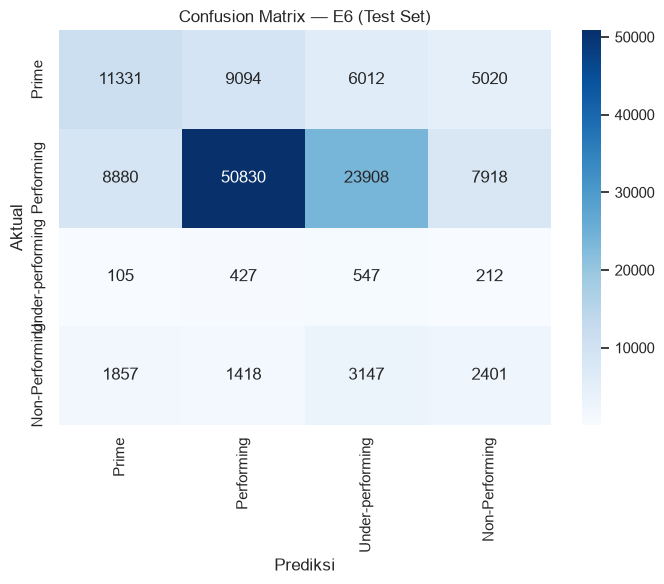

In [14]:
cm = confusion_matrix(y_test, best_y_pred)
cm_labels = [label_names[i] for i in sorted(label_names)]

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=cm_labels, yticklabels=cm_labels,
)
plt.title(f'Confusion Matrix — {best_exp_id} (Test Set)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'confusion_matrix_best_model.png'), dpi=120)
plt.show()

## Menyimpan Model Terbaik & Riwayat Eksperimen

In [15]:
model_path = os.path.join(MODELS, 'best_model.keras')
best_model.save(model_path)

results_df.to_csv(os.path.join(REPORTS, 'experiment_results.csv'))
save_json(
    {'best_exp_id': best_exp_id, 'config': EXPERIMENTS[best_exp_id]},
    'best_model_info.json',
)

print(f'Model terbaik disimpan di: {model_path}')
print('Hasil eksperimen disimpan di: reports/experiment_results.csv')

Model terbaik disimpan di: c:\Users\Yosua Triantara\Documents\Kuliah\Mata Kuliah\SEMESTER 6\DEEP LEARNING\creditScoring\models\best_model.keras
Hasil eksperimen disimpan di: reports/experiment_results.csv


## Ringkasan

Keenam skenario eksperimen (baseline, dropout, batch normalization, kombinasi, dan penanganan class imbalance lewat class weight) telah dilatih dan dievaluasi. Model dengan F1-score macro terbaik disimpan di `models/best_model.keras`.
